    Experience (Years)  Salary (₹)
0                    1       25000
1                    2       30000
2                    3       35000
3                    4       42000
4                    5       48000
5                    6       55000
6                    7       62000
7                    8       70000
8                    9       77000
9                   10       85000
10                  11       93000
11                  12      101000
12                  13      110000
13                  14      119000
14                  15      128000

Slope: 7607.664954563413
Intercept: 10921.374950612415

Salary = 7607.66 × Experience + 10921.37

Training R² Score : 0.9961008078398366
Testing R² Score  : 0.9852561289401639
RMSE : 3972.306439565769

Predicted Salaries
4 Years Experience --> ₹41,352
8 Years Experience --> ₹71,783
16 Years Experience --> ₹132,644


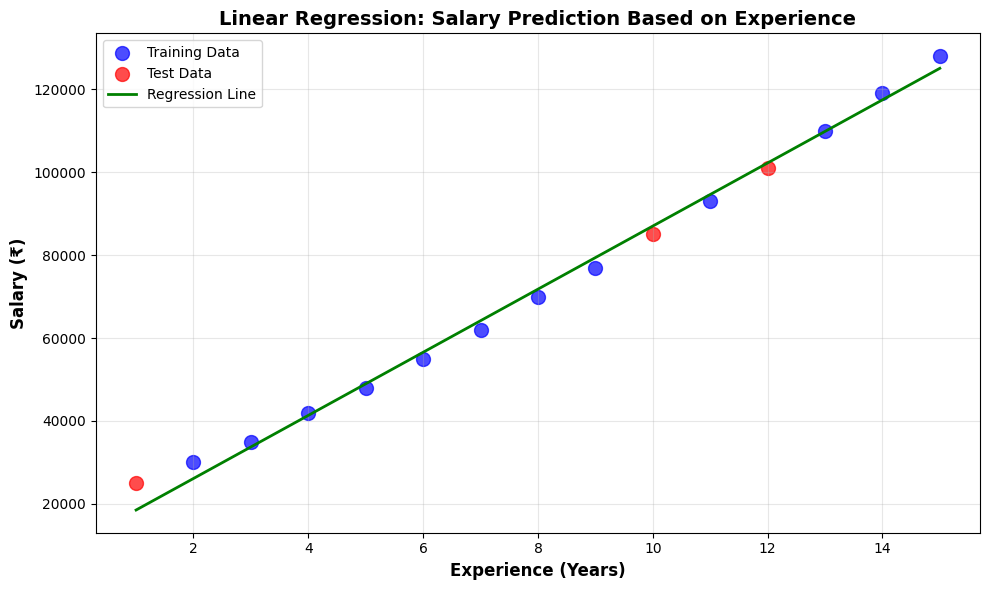

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

experience = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]).reshape(-1,1)
salary = np.array([25000,30000,35000,42000,48000,55000,62000,70000,77000,85000,93000,101000,110000,119000,128000])
df = pd.DataFrame({
    "Experience (Years)": experience.flatten(),
    "Salary (₹)": salary})
print(df)

X_train, X_test, y_train, y_test = train_test_split(experience,salary,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
print("\nSlope:", model.coef_[0])
print("Intercept:", model.intercept_)
print(f"\nSalary = {model.coef_[0]:.2f} × Experience + {model.intercept_:.2f}")

print("\nTraining R² Score :", r2_score(y_train, y_pred_train))
print("Testing R² Score  :", r2_score(y_test, y_pred_test))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))

new_experience = np.array([[4], [8], [16]])
predicted_salary = model.predict(new_experience)
print("\nPredicted Salaries")
for exp, sal in zip(new_experience, predicted_salary):
    print(f"{exp[0]} Years Experience --> ₹{sal:,.0f}")


plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train,color='blue',label='Training Data',s=100,alpha=0.7)
plt.scatter(X_test, y_test,color='red',label='Test Data',s=100,alpha=0.7)


X_range = np.array([[experience.min()],[experience.max()]])
y_range = model.predict(X_range)
plt.plot(X_range,y_range,color='green',linewidth=2,label='Regression Line')
plt.xlabel("Experience (Years)", fontsize=12, fontweight='bold')
plt.ylabel("Salary (₹)", fontsize=12, fontweight='bold')
plt.title("Linear Regression: Salary Prediction Based on Experience",fontsize=14,fontweight='bold')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()